# Birds of the World: Cleaning, Visualization, and Analysis

This notebook reconstructs a malformed CSV, cleans the dataset, performs exploratory analysis, and saves visualizations.


## 1. Imports and configuration

In [4]:
!pip install pandas matplotlib

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- -------------------------------------

In [5]:
import csv
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

INPUT_CSV = "Birdsoftheworld.csv"
OUTPUT_DIR = Path("Birdworld_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Rebuild the malformed CSV

The CSV is not cleanly serialized because some text fields contain commas that were not quoted properly.  
Instead of trusting fixed column positions, we:

1. detect the timestamp column dynamically
2. treat everything before it as `species` + `location`
3. treat everything after it as `description` + `sex` + `feather_color`

In [6]:
def rebuild_dataset(input_csv: str) -> pd.DataFrame:
    """
    Rebuild a malformed CSV where commas inside text fields were not properly quoted.

    Expected logical columns:
    - species
    - location
    - time
    - description
    - sex
    - feather_color
    """
    dt_re = re.compile(r"^\d{2}-\d{2}-\d{4} \d{2}:\d{2}$")
    records = []

    with open(input_csv, newline="", encoding="utf-8") as f:
        rows = list(csv.reader(f))

    for row in rows[1:]:  # skip header
        time_idx = next((i for i, cell in enumerate(row) if dt_re.match(cell.strip())), None)
        if time_idx is None:
            continue

        species = row[0].strip()
        location = ",".join(x.strip() for x in row[1:time_idx]).strip()
        time = row[time_idx].strip()

        post = [x for x in row[time_idx + 1:] if x != ""]
        combined = ",".join(post).rstrip(",")

        # Preferred parse: description,sex,feather_color
        m = re.match(r"^(.*),(Male|Female|Unknown),(.*)$", combined)
        if m:
            description, sex, feather_color = m.groups()
        else:
            # Fallback if sex exists but feather color is missing
            m2 = re.match(r"^(.*),(Male|Female|Unknown)$", combined)
            if m2:
                description, sex = m2.groups()
                feather_color = ""
            else:
                continue

        records.append(
            {
                "species": species,
                "location": location,
                "time": time,
                "description": description.strip().strip('"'),
                "sex": sex.strip(),
                "feather_color": feather_color.strip().strip('"'),
            }
        )

    return pd.DataFrame(records)

## 3. Load the reconstructed dataset

In [7]:
raw_df = rebuild_dataset(INPUT_CSV)
print("Raw reconstructed shape:", raw_df.shape)
raw_df.head()

Raw reconstructed shape: (1310, 6)


,species,location,time,description,sex,feather_color
0,American Robin,New York City,15-06-2023 08:30,A medium-sized bird with an orange breast and ...,Unknown,Brown
1,Bald Eagle,Seattle,02-07-2023 12:45,A large bird of prey with a white head and bro...,Male,Brown and White
2,Northern Cardinal,Miami,29-06-2023 16:15,A small red bird with a crest on its head,Female,Red
3,Blue Jay,Chicago,05-07-2023 10:00,A medium-sized bird with blue feathers and a b...,Unknown,Blue and Black
4,Ruby-throated Hummingbird,Los Angeles,20-06-2023 09:00,A tiny bird with green feathers and a ruby-red...,Male,Green and Red


## 4. Clean the dataset

Cleaning steps:
- strip whitespace
- parse timestamps
- remove invalid datetime rows
- standardize `sex`
- create helpful derived fields
- split feather colors into a list
- remove exact duplicate records

In [8]:
def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Standardize strings
    text_cols = ["species", "location", "description", "sex", "feather_color"]
    for col in text_cols:
        df[col] = df[col].astype(str).str.strip()

    # Parse datetime
    df["time_parsed"] = pd.to_datetime(df["time"], format="%d-%m-%Y %H:%M", errors="coerce")

    # Remove rows with invalid dates
    df = df.dropna(subset=["time_parsed"]).copy()

    # Derived fields
    df["year"] = df["time_parsed"].dt.year
    df["month"] = df["time_parsed"].dt.month
    df["hour"] = df["time_parsed"].dt.hour
    df["description_length"] = df["description"].str.len()

    # Normalize sex values
    df["sex"] = df["sex"].replace(
        {
            "male": "Male",
            "female": "Female",
            "unknown": "Unknown",
        }
    )

    # Split feather colors into tokens
    def split_colors(s: str):
        s = s.replace(", and ", ",").replace(" and ", ",")
        return [x.strip().lower() for x in s.split(",") if x.strip()]

    df["color_list"] = df["feather_color"].apply(split_colors)
    df["color_count"] = df["color_list"].apply(len)

    # Drop exact duplicates based on logical raw columns
    df = df.drop_duplicates(
        subset=["species", "location", "time", "description", "sex", "feather_color"]
    ).reset_index(drop=True)

    return df

In [9]:
clean_df = clean_dataset(raw_df)
print("Cleaned shape:", clean_df.shape)
clean_df.head()

Cleaned shape: (1302, 13)


,species,location,time,description,sex,feather_color,time_parsed,year,month,hour,description_length,color_list,color_count
0,American Robin,New York City,15-06-2023 08:30,A medium-sized bird with an orange breast and ...,Unknown,Brown,2023-06-15 08:30:00,2023,6,8,58,[brown],1
1,Bald Eagle,Seattle,02-07-2023 12:45,A large bird of prey with a white head and bro...,Male,Brown and White,2023-07-02 12:45:00,2023,7,12,53,"[brown, white]",2
2,Northern Cardinal,Miami,29-06-2023 16:15,A small red bird with a crest on its head,Female,Red,2023-06-29 16:15:00,2023,6,16,41,[red],1
3,Blue Jay,Chicago,05-07-2023 10:00,A medium-sized bird with blue feathers and a b...,Unknown,Blue and Black,2023-07-05 10:00:00,2023,7,10,56,"[blue, black]",2
4,Ruby-throated Hummingbird,Los Angeles,20-06-2023 09:00,A tiny bird with green feathers and a ruby-red...,Male,Green and Red,2023-06-20 09:00:00,2023,6,9,53,"[green, red]",2


## 5. Quick quality checks

In [10]:
print("Missing values:")
print(clean_df[["species", "location", "time", "description", "sex", "feather_color"]].isna().sum())

print("\nDate range:")
print(clean_df["time_parsed"].min(), "to", clean_df["time_parsed"].max())

print("\nUnique species:", clean_df["species"].nunique())
print("Unique locations:", clean_df["location"].nunique())

print("\nSex distribution:")
print(clean_df["sex"].value_counts())

Missing values:
species          0
location         0
time             0
description      0
sex              0
feather_color    0
dtype: int64

Date range:
2001-03-17 12:40:00 to 2023-07-09 14:10:00

Unique species: 534
Unique locations: 124

Sex distribution:
sex
Unknown    945
Male       352
Female       5
Name: count, dtype: int64


## 6. Summary tables

In [11]:
def summarize_dataset(df: pd.DataFrame):
    summary = {
        "rows": len(df),
        "columns": len(df.columns),
        "unique_species": df["species"].nunique(),
        "unique_locations": df["location"].nunique(),
        "date_min": df["time_parsed"].min(),
        "date_max": df["time_parsed"].max(),
        "sex_distribution": df["sex"].value_counts().to_dict(),
    }

    top_species = (
        df["species"]
        .value_counts()
        .head(10)
        .rename_axis("species")
        .reset_index(name="count")
    )

    top_locations = (
        df.groupby("location")
        .agg(
            observations=("species", "size"),
            unique_species=("species", "nunique"),
        )
        .sort_values(["observations", "unique_species"], ascending=False)
        .head(10)
        .reset_index()
    )

    color_counter = Counter(color for colors in df["color_list"] for color in colors)
    top_colors = (
        pd.Series(color_counter)
        .sort_values(ascending=False)
        .head(10)
        .rename_axis("color")
        .reset_index(name="count")
    )

    return summary, top_species, top_locations, top_colors

summary, top_species, top_locations, top_colors = summarize_dataset(clean_df)

summary

{'rows': 1302,
 'columns': 13,
 'unique_species': 534,
 'unique_locations': 124,
 'date_min': Timestamp('2001-03-17 12:40:00'),
 'date_max': Timestamp('2023-07-09 14:10:00'),
 'sex_distribution': {'Unknown': 945, 'Male': 352, 'Female': 5}}

In [12]:
top_species

,species,count
0,Ruby-throated Hummingbird,27
1,Blue Jay,25
2,American Goldfinch,25
3,Northern Flicker,25
4,American Robin,20
5,American Crow,20
6,Downy Woodpecker,20
7,Belted Kingfisher,9
8,Scarlet Tanager,9
9,Green Heron,9


In [13]:
top_locations

,location,observations,unique_species
0,United States,626,251
1,Seattle,42,31
2,New York City,40,29
3,London,33,28
4,Chicago,28,22
5,United Kingdom,23,22
6,Sydney,22,17
7,Denver,21,15
8,Los Angeles,20,19
9,Miami,19,19


In [14]:
top_colors

,color,count
0,white,496
1,black,479
2,brown,224
3,yellow,174
4,red,148
5,gray,126
6,blue,104
7,green,94
8,grayish-brown,74
9,brownish,44


## 7. Visualizations

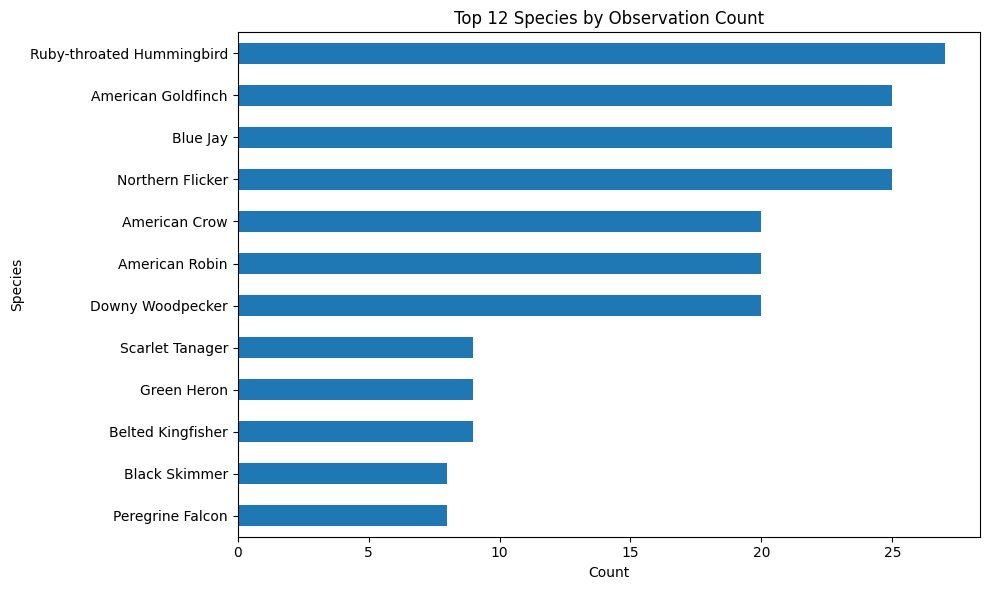

In [15]:
# Top species
plt.figure(figsize=(10, 6))
clean_df["species"].value_counts().head(12).sort_values().plot(kind="barh")
plt.title("Top 12 Species by Observation Count")
plt.xlabel("Count")
plt.ylabel("Species")
plt.tight_layout()
plt.show()

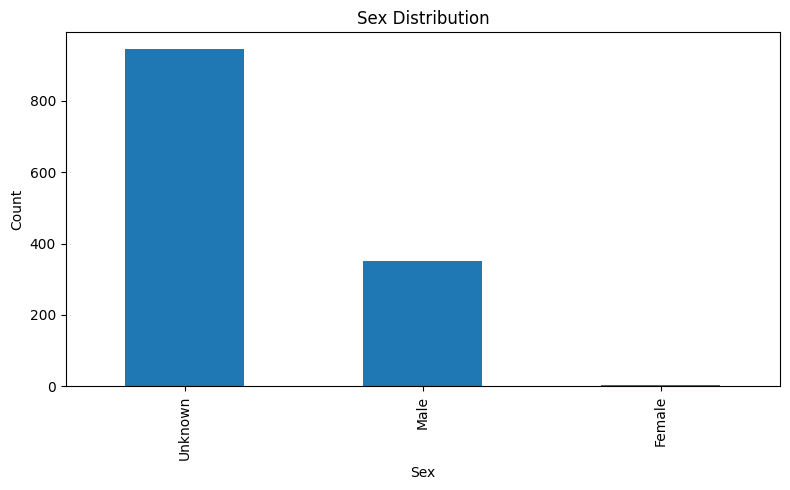

In [16]:
# Sex distribution
plt.figure(figsize=(8, 5))
clean_df["sex"].value_counts().plot(kind="bar")
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

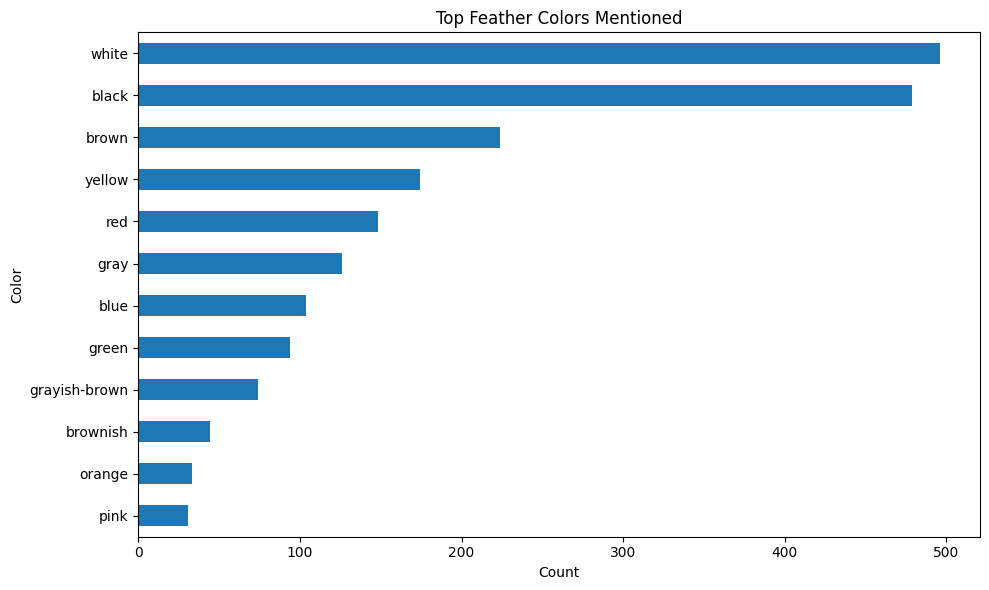

In [17]:
# Top feather colors
color_counter = Counter(color for colors in clean_df["color_list"] for color in colors)

plt.figure(figsize=(10, 6))
pd.Series(color_counter).sort_values(ascending=False).head(12).sort_values().plot(kind="barh")
plt.title("Top Feather Colors Mentioned")
plt.xlabel("Count")
plt.ylabel("Color")
plt.tight_layout()
plt.show()

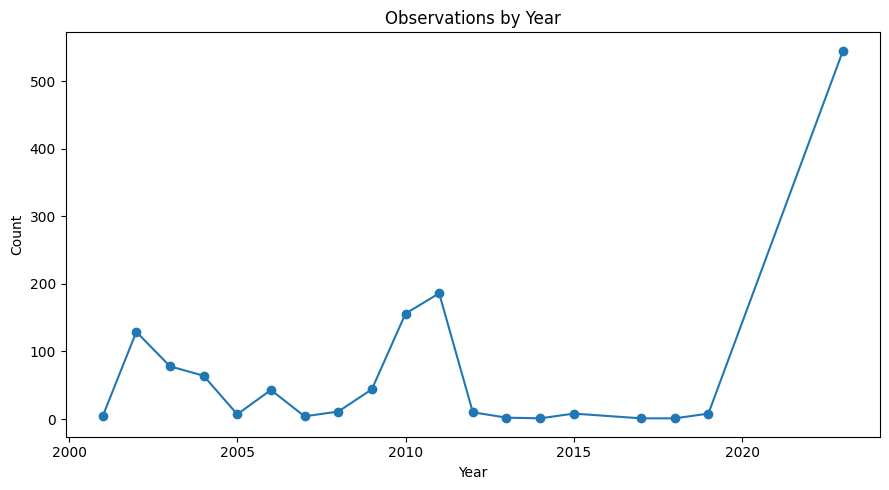

In [18]:
# Observations by year
plt.figure(figsize=(9, 5))
clean_df["year"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Observations by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

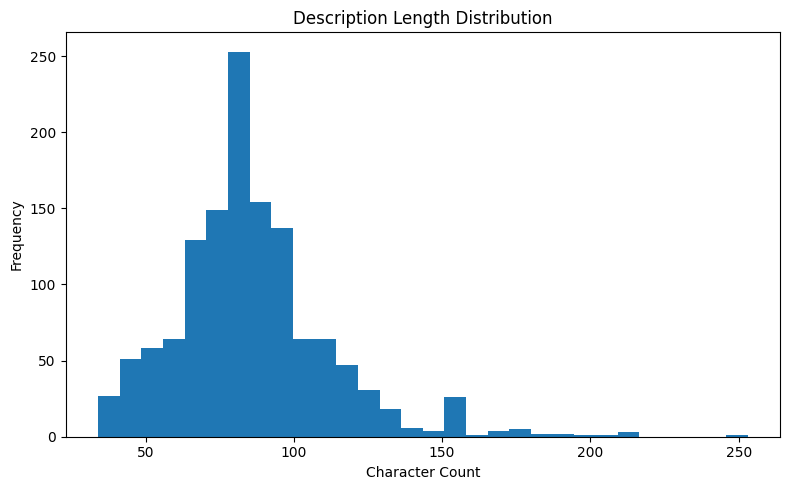

In [19]:
# Description length distribution
plt.figure(figsize=(8, 5))
clean_df["description_length"].plot(kind="hist", bins=30)
plt.title("Description Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 8. Save cleaned data and chart files

In [20]:
def save_visualizations(df: pd.DataFrame, output_dir: Path):
    # Top species
    plt.figure(figsize=(10, 6))
    df["species"].value_counts().head(12).sort_values().plot(kind="barh")
    plt.title("Top 12 Species by Observation Count")
    plt.xlabel("Count")
    plt.ylabel("Species")
    plt.tight_layout()
    plt.savefig(output_dir / "top_species.png", dpi=150)
    plt.close()

    # Sex distribution
    plt.figure(figsize=(8, 5))
    df["sex"].value_counts().plot(kind="bar")
    plt.title("Sex Distribution")
    plt.xlabel("Sex")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(output_dir / "sex_distribution.png", dpi=150)
    plt.close()

    # Top feather colors
    color_counter = Counter(color for colors in df["color_list"] for color in colors)
    plt.figure(figsize=(10, 6))
    pd.Series(color_counter).sort_values(ascending=False).head(12).sort_values().plot(kind="barh")
    plt.title("Top Feather Colors Mentioned")
    plt.xlabel("Count")
    plt.ylabel("Color")
    plt.tight_layout()
    plt.savefig(output_dir / "top_colors.png", dpi=150)
    plt.close()

    # Observations by year
    plt.figure(figsize=(9, 5))
    df["year"].value_counts().sort_index().plot(kind="line", marker="o")
    plt.title("Observations by Year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(output_dir / "observations_by_year.png", dpi=150)
    plt.close()

    # Description length distribution
    plt.figure(figsize=(8, 5))
    df["description_length"].plot(kind="hist", bins=30)
    plt.title("Description Length Distribution")
    plt.xlabel("Character Count")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(output_dir / "description_length_hist.png", dpi=150)
    plt.close()

save_visualizations(clean_df, OUTPUT_DIR)

clean_df.drop(columns=["color_list"]).to_csv(OUTPUT_DIR / "Birdsoftheworld_cleaned.csv", index=False)

print("Saved cleaned CSV and charts to:", OUTPUT_DIR.resolve())

Saved cleaned CSV and charts to: C:\Users\Iya\Documents\Programming Workspace\birds-analysis\Birdworld_outputs


## 9. Final notes

This notebook uses a reconstruction step because the source CSV is malformed.  
That is why a normal `pd.read_csv()` call would produce extra broken columns.

You can extend this notebook with:
- word frequency analysis on `description`
- species-by-location cross tabs
- seasonal analysis by month
- richer text cleaning for `feather_color`